In [1]:
# 🚀 1. IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_theme(style="darkgrid")

In [2]:
# 🚀 2. DATA LOADING
# ============================================================
df = pd.read_csv("./dataset/TRAIN_DATA.csv")

print("Shape:", df.shape)

Shape: (2000, 16)


In [3]:
# ============================================================
# 🚀 3. DATA PREPROCESSING
# ============================================================
df = df.dropna(subset=["Class/ASD"])
df.fillna(df.mode().iloc[0], inplace=True)
df.drop_duplicates(inplace=True)

# Encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    
print("Preprocessing complete. Current shape:", df.shape)

Preprocessing complete. Current shape: (1991, 16)


In [4]:
# ============================================================
# 🚀 4. FEATURE ENGINEERING
# ============================================================
# ❗ Remove leakage
if "total_score" in df.columns:
    df.drop("total_score", axis=1, inplace=True)

# Create features
score_cols = [f"A{i}_Score" for i in range(1,11)]

df['sum_score'] = df[score_cols].sum(axis=1)
df['age_score'] = df['age'] * df['sum_score']
df['risk_flag'] = (df['sum_score'] >= 7).astype(int)

df.head()

,age,jaundice,austim,gender,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,Class/ASD,sum_score,age_score,risk_flag
0,43,1,1,1,0,0,1,1,0,0,0,0,1,0,1,3,129,0
1,56,1,0,0,0,1,1,1,0,0,1,1,0,0,0,5,280,0
2,33,0,0,0,0,0,1,1,0,1,0,1,0,0,0,4,132,0
3,19,1,1,0,1,1,0,1,0,1,1,0,0,0,1,5,95,0
4,47,0,1,0,0,0,1,1,1,0,1,0,0,0,0,4,188,0


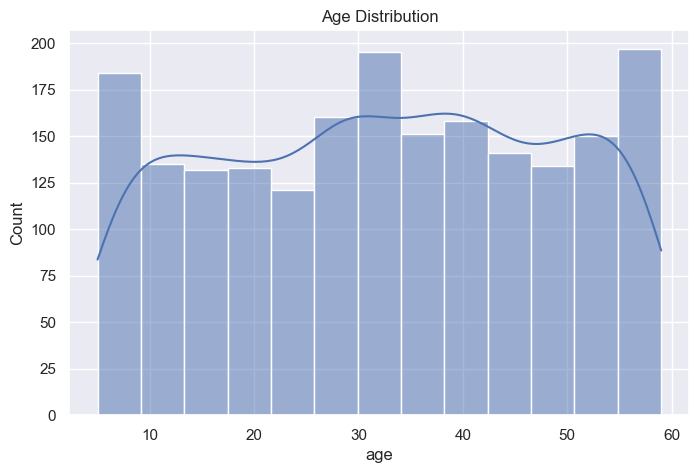

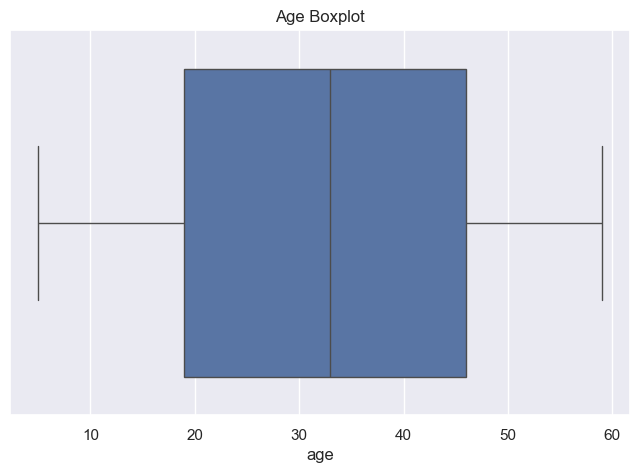

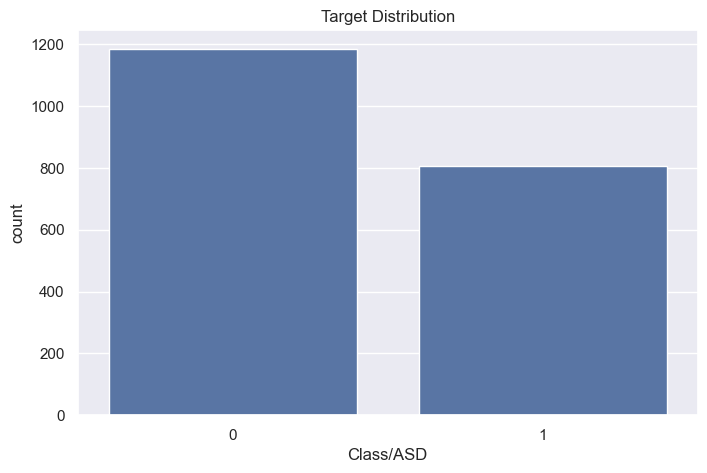

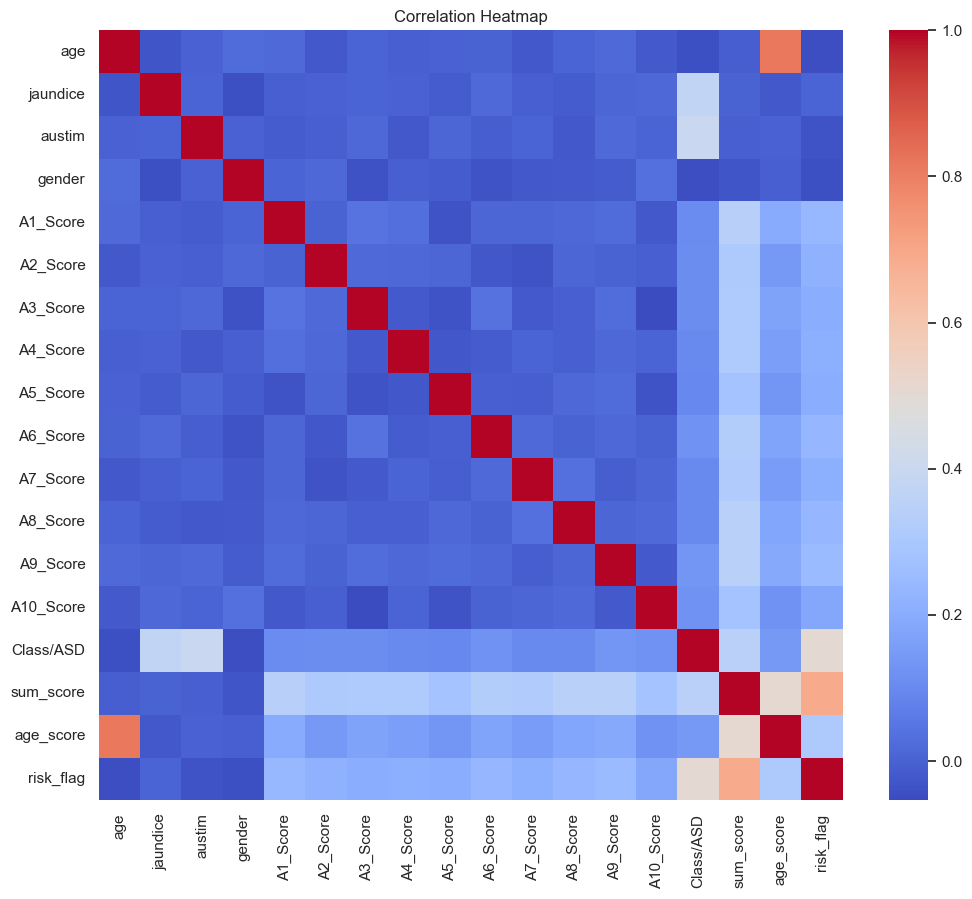

In [5]:
# ============================================================
# 🚀 5. EDA
# ============================================================
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['age'])
plt.title("Age Boxplot")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Class/ASD', data=df)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [6]:
# ============================================================
# 🚀 7 & 8. BOX-COX / POWER TRANSFORM & SCALING
# ============================================================
X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]

X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.2,
	random_state=42,
	stratify=y
)

# Power Transform
pt = PowerTransformer(method="yeo-johnson")  # works with 0 values
X_train_pt = pt.fit_transform(X_train)
X_test_pt = pt.transform(X_test)

# Scaling (IMPORTANT FOR LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pt)
X_test_scaled = scaler.transform(X_test_pt)

print("Transformations and scaling applied.")

Transformations and scaling applied.


In [7]:
# ============================================================
# 🚀 9. FEATURE SELECTION
# ============================================================
selector = SelectKBest(f_classif, k=10)
X_train_final = selector.fit_transform(X_train_scaled, y_train)
X_test_final = selector.transform(X_test_scaled)

print(f"Selected {X_train_final.shape[1]} features out of {X_train.shape[1]}")

Selected 10 features out of 17


In [ ]:
# ============================================================
# 🚀 10. MODEL TRAINING
# ============================================================
# Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_final, y_train)
y_pred_lr = lr.predict(X_test_final)

print("Models trained successfully.")

Models trained successfully.


In [12]:
# ============================================================
# 🚀 11. MODEL COMPARISON
# ============================================================
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr)
    ]
})

print("\nMODEL COMPARISON:\n")
display(results) # display() renders dataframes nicely in Jupyter


MODEL COMPARISON:



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.924812,0.917197,0.89441,0.90566


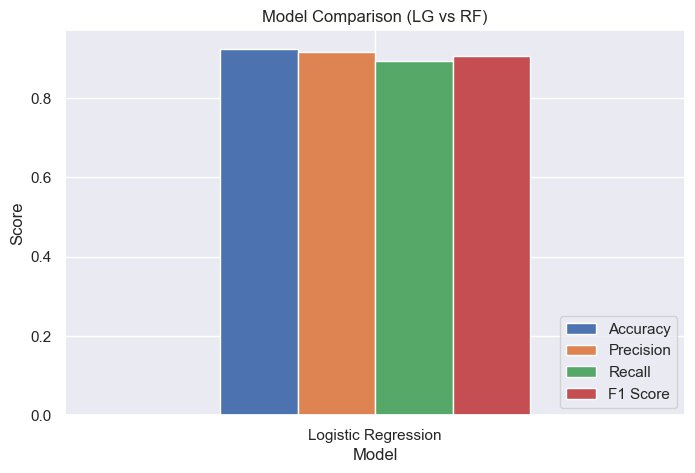

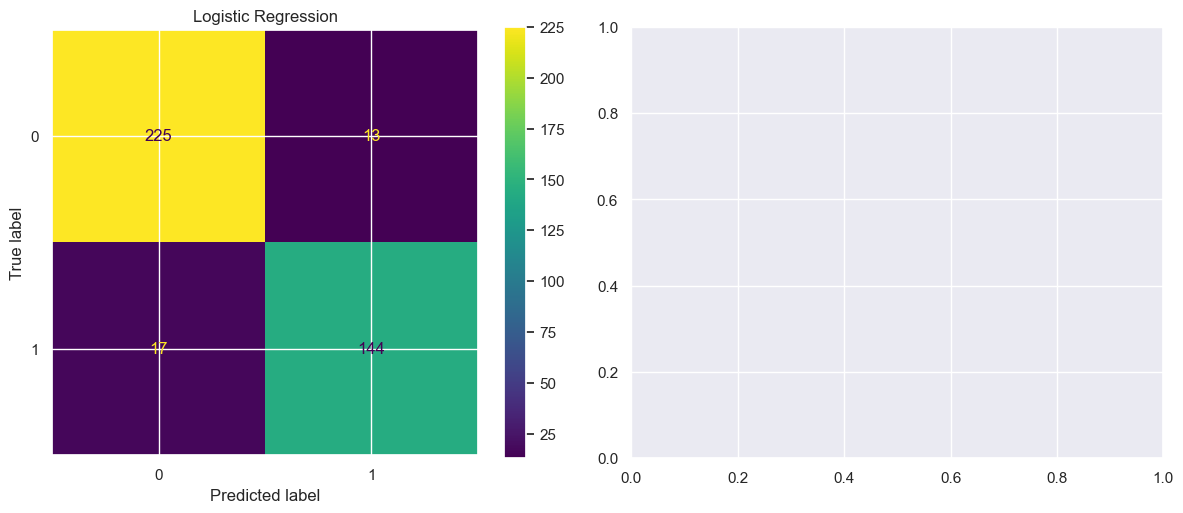

In [13]:
# ============================================================
# 🚀 12 & 13. COMPARISON GRAPH & CONFUSION MATRICES
# ============================================================
# Bar chart comparison
results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison (LG vs RF)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(lr, X_test_final, y_test, ax=ax[0])
ax[0].set_title("Logistic Regression")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 🚀 14. FINAL OUTPUT
# ============================================================
print("\nFINAL RESULTS:")

print("\nLogistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")


FINAL RESULTS:

Logistic Regression:
Accuracy: 0.9248
